In [ ]:
install.packages("BiocManager")
install.packages("tidyverse")
install.packages("dplyr")
BiocManager::install("GEOquery")
BiocManager::install("DESeq2")
BiocManager::install("topconfects")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'BiocVersion', 'GEOquery'

also installing the dependencies ‘zlibbioc’, ‘matrixStats’, ‘XVector’, ‘UCSC.utils’, ‘GenomeInfoDbData’, ‘abind’, ‘SparseArray’, ‘BiocGenerics’, ‘statmod’, ‘XML’, ‘R.oo’, ‘R.methodsS3’, ‘MatrixGenerics’, ‘GenomicRanges’, ‘IRanges’, ‘GenomeInfoDb’, ‘S4Arrays’, ‘DelayedArray’, ‘Biobase’, ‘limma’, ‘rentrez’, ‘R.utils’, ‘SummarizedExperiment’, ‘S4Vectors’


Old packages: 'cluster'

'getOption("repos")' replaces Bioconductor standard repos

In [ ]:
library(tidyverse)
library(dplyr)
library(GEOquery)
library(DESeq2)
library(topconfects)
library(tidyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append,

## GSE57957

In [ ]:
accessionID = "GSE57957"

In [ ]:
# get metadata --------
gse <- getGEO(GEO = accessionID, GSEMatrix = TRUE)
head(gse)

Found 1 file(s)

GSE57957_series_matrix.txt.gz

Using locally cached version: /tmp/RtmpTVkYlS/GSE57957_series_matrix.txt.gz

Using locally cached version of GPL10558 found here:
/tmp/RtmpTVkYlS/GPL10558.soft.gz 



$GSE57957_series_matrix.txt.gz
ExpressionSet (storageMode: lockedEnvironment)
assayData: 47323 features, 78 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: GSM1398645 GSM1398646 ... GSM1398722 (78 total)
  varLabels: title geo_accession ... tissue:ch1 (34 total)
  varMetadata: labelDescription
featureData
  featureNames: ILMN_1343291 ILMN_1343295 ... ILMN_3311190 (47323
    total)
  fvarLabels: ID Species ... GB_ACC (30 total)
  fvarMetadata: Column Description labelDescription
experimentData: use 'experimentData(object)'
  pubMedIds: 25093504 
Annotation: GPL10558 


In [ ]:
countsData <- as.data.frame(exprs(gse[[1]]))

In [ ]:
dim(countsData)

[1] 47323    78

In [ ]:
head(countsData)

,GSM1398645,GSM1398646,GSM1398647,GSM1398648,GSM1398649,GSM1398650,GSM1398651,GSM1398652,GSM1398653,GSM1398654,⋯,GSM1398713,GSM1398714,GSM1398715,GSM1398716,GSM1398717,GSM1398718,GSM1398719,GSM1398720,GSM1398721,GSM1398722
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ILMN_1343291,36440.400,35594.600,31413.100,38588.100,46348.300,40619.000,48889.500,37005.600,47001.500,26061.600,⋯,38208.200,44213.300,44884.500,39361.800,36440.400,46348.300,31621.700,44884.500,42586.400,48889.500
ILMN_1343295,6073.240,4180.330,10289.800,5898.370,6121.350,4448.740,4871.340,5898.370,7427.820,17030.800,⋯,4373.580,3843.540,5143.520,15843.200,7135.330,7393.990,5750.710,7771.190,5107.940,14839.200
ILMN_1651199,141.423,144.948,178.386,150.837,165.730,172.389,173.080,177.562,168.735,157.183,⋯,152.081,137.396,170.116,173.029,159.156,156.030,167.864,137.436,172.139,185.788
ILMN_1651209,176.778,161.086,151.647,154.021,179.005,167.586,173.917,162.643,174.635,151.007,⋯,158.525,177.314,173.328,146.833,171.644,168.848,161.248,165.693,169.151,149.326
ILMN_1651210,188.431,213.394,191.150,192.495,195.181,181.526,194.385,222.267,175.208,170.176,⋯,212.500,193.547,186.883,178.204,183.738,186.433,173.116,198.724,177.255,192.055
ILMN_1651221,196.387,228.266,184.547,230.931,202.958,223.045,218.680,217.864,200.373,216.235,⋯,207.984,211.715,208.555,214.654,192.151,225.960,246.743,248.115,207.532,215.420


In [ ]:
countsData <- countsData %>% drop_na()

In [ ]:
countsData <- countsData %>% filter(rowSums(.< 0) == 0)

In [ ]:
metaData <- pData(phenoData(gse[[1]]))

In [ ]:
dim(metaData)

[1] 78 34

In [ ]:
head(metaData)

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,⋯,contact_department,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,data_row_count,disease state:ch1,tissue:ch1
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM1398645,RNA from HCC_1T,GSM1398645,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_1T,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,hepatocellular carcinoma tumor,liver tissue
GSM1398646,RNA from HCC_2N,GSM1398646,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_2N,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,adjacent non-tumorous,liver tissue
GSM1398647,RNA from HCC_2T,GSM1398647,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_2T,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,hepatocellular carcinoma tumor,liver tissue
GSM1398648,RNA from HCC_3N,GSM1398648,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_3N,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,adjacent non-tumorous,liver tissue
GSM1398649,RNA from HCC_3T,GSM1398649,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_3T,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,hepatocellular carcinoma tumor,liver tissue
GSM1398650,RNA from HCC_4N,GSM1398650,Public on Dec 10 2014,May 24 2014,Dec 10 2014,RNA,1,HCC_4N,Homo sapiens,tissue: liver tissue,⋯,"Department of Biochemistry, National University of Singapore",National Cancer Centre Singapore,11 Hospital Drive,Singapore,169610,Singapore,NONE,47323,adjacent non-tumorous,liver tissue


In [ ]:
colnames(metaData)

[1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "molecule_ch1"           
[13] "extract_protocol_ch1"    "label_ch1"              
[15] "label_protocol_ch1"      "taxid_ch1"              
[17] "hyb_protocol"            "scan_protocol"          
[19] "description"             "data_processing"        
[21] "platform_id"             "contact_name"           
[23] "contact_email"           "contact_laboratory"     
[25] "contact_department"      "contact_institute"      
[27] "contact_address"         "contact_city"           
[29] "contact_zip/postal_code" "contact_country"        
[31] "supplementary_file"      "data_row_count"         
[33] "disease state:ch1"       "tissue:ch1"

In [ ]:
unique(metaData$characteristics_ch1.1)

[1] "disease state: hepatocellular carcinoma tumor"
[2] "disease state: adjacent non-tumorous"

In [ ]:
metaData.modified <- metaData %>%
  select(11) %>%
  mutate(characteristics_ch1.1 = gsub("disease state: hepatocellular carcinoma tumor", "tumor", characteristics_ch1.1)) %>%
  mutate(characteristics_ch1.1 = gsub("disease state: adjacent non-tumorous", "non_tumor", characteristics_ch1.1))
  #rename(tissue = characteristics_ch1) %>%
  #rename(metastasis = characteristics_ch1.1) %>%
  #mutate(tissue = gsub("tissue: ", "", tissue)) %>%
  #mutate(metastasis = gsub("metastasis: ", "", metastasis))

In [ ]:
head(metaData.modified)

,characteristics_ch1.1
,<chr>
GSM1398645,tumor
GSM1398646,non_tumor
GSM1398647,tumor
GSM1398648,non_tumor
GSM1398649,tumor
GSM1398650,non_tumor


In [ ]:
unique(metaData.modified$characteristics_ch1.1)

[1] "tumor"     "non_tumor"

In [ ]:
table(metaData.modified$characteristics_ch1.1)


non_tumor     tumor 
       39        39 

In [ ]:
# Make sure the row names in metaData matches to column names in countsData
all(colnames(countsData) %in% rownames(metaData.modified))

[1] TRUE

In [ ]:
# Make sure the row names in metaData is in the same order with the column names in countsData
all(colnames(countsData) == rownames(metaData.modified))

[1] TRUE

In [ ]:
any(is.na(countsData))

[1] FALSE

In [ ]:
any(countsData < 0)

[1] FALSE

In [ ]:
dds <- DESeqDataSetFromMatrix(countData = round(countsData),
                       colData = metaData.modified,
                       design = ~ characteristics_ch1.1)

dds

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 47323 78 
metadata(1): version
assays(1): counts
rownames(47323): ILMN_1343291 ILMN_1343295 ... ILMN_3311185
  ILMN_3311190
rowData names(0):
colnames(78): GSM1398645 GSM1398646 ... GSM1398721 GSM1398722
colData names(1): characteristics_ch1.1

In [ ]:
# Pre-filtering: remove rows with low gene counts; keep rows that have at least 100 reads total
keep <- rowSums(counts(dds)) >= 100
dds <- dds[keep,]

dds

class: DESeqDataSet 
dim: 47323 78 
metadata(1): version
assays(1): counts
rownames(47323): ILMN_1343291 ILMN_1343295 ... ILMN_3311185
  ILMN_3311190
rowData names(0):
colnames(78): GSM1398645 GSM1398646 ... GSM1398721 GSM1398722
colData names(1): characteristics_ch1.1

In [ ]:
dds

class: DESeqDataSet 
dim: 47323 78 
metadata(1): version
assays(1): counts
rownames(47323): ILMN_1343291 ILMN_1343295 ... ILMN_3311185
  ILMN_3311190
rowData names(0):
colnames(78): GSM1398645 GSM1398646 ... GSM1398721 GSM1398722
colData names(1): characteristics_ch1.1

In [ ]:
# set the factor level
dds$characteristics_ch1.1 <- relevel(dds$characteristics_ch1.1, ref = "non_tumor")

In [ ]:
# Step 3: Run DESeq ----------------------
dds <- DESeq(dds)
res <- results(dds)

res

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 656 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): characteristics ch1.1 tumor vs non tumor 
Wald test p-value: characteristics ch1.1 tumor vs non tumor 
DataFrame with 47323 rows and 6 columns
              baseMean log2FoldChange     lfcSE      stat      pvalue
             <numeric>      <numeric> <numeric> <numeric>   <numeric>
ILMN_1343291 39080.682      0.2222319 0.0532196  4.175753 2.97002e-05
ILMN_1343295  7591.658      0.5697311 0.1154684  4.934088 8.05260e-07
ILMN_1651199   167.894     -0.0663168 0.0327868 -2.022669 4.31073e-02
ILMN_1651209   159.875     -0.0114431 0.0307671 -0.371928 7.09947e-01
ILMN_1651210   184.550     -0.0250782 0.0340371 -0.736789 4.61251e-01
...                ...            ...       ...       ...         ...
ILMN_3311170   149.964     -0.0119078 0.0344405 -0.345749    0.729532
ILMN_3311175   175.108      0.0043221 0.0296857  0.145595    0.884241
ILMN_3311180   210.532     -0.0375141 0.0309735 -1.211164    0.225832
ILMN_3311185   149.837     -0.0281523 0.0293348 -0.959691    0.

In [ ]:
# Explore Results ----------------

summary(res)


out of 47323 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 9639, 20%
LFC < 0 (down)     : 7491, 16%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 79)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res0.05 <- results(dds, alpha = 0.05)
summary(res0.05)


out of 47323 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 8594, 18%
LFC < 0 (down)     : 5527, 12%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 79)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res = as.data.frame(res0.05)

In [ ]:
any(is.na(res))

[1] FALSE

In [ ]:
res <- res %>% drop_na()

In [ ]:
res$diffexpressed <- ifelse(res$log2FoldChange > 0 & res$padj < 0.05, "UP",
                       ifelse(res$log2FoldChange < 0 & res$padj < 0.05, "DOWN", "N0"))

res$delabel <- "NA"

In [ ]:
table(res$diffexpressed)


 DOWN    N0    UP 
 5527 33202  8594 

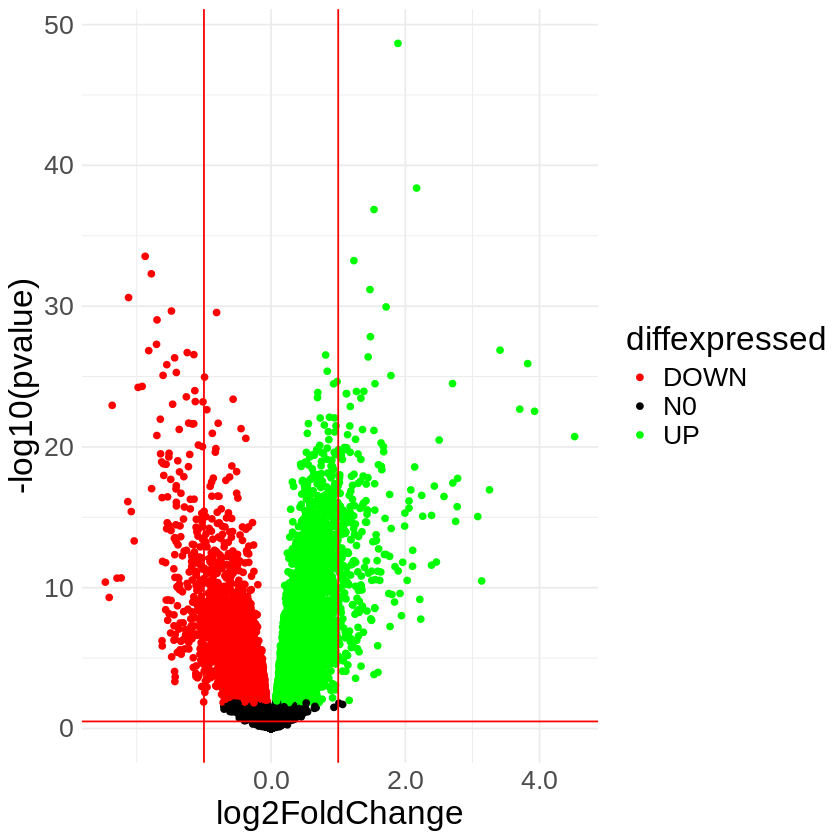

In [ ]:
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0, 6, by = 2), labels = c("0.0", "2.0", "4.0", "6.0")) +
    geom_vline(xintercept = c(-1.0,  1.0), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))

In [ ]:
# Volcano plot
jpeg(file=sprintf("Volcano Plot - %s.jpeg", accessionID), width = 800, height = 800)
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0, 6, by = 2), labels = c("0.0", "2.0", "4.0", "6.0")) +
    geom_vline(xintercept = c(-1.0,  1.0), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))
dev.off()

pdf 
  2

In [ ]:
# contrasts
resultsNames(dds)

[1] "Intercept"                               
[2] "characteristics_ch1.1_tumor_vs_non_tumor"

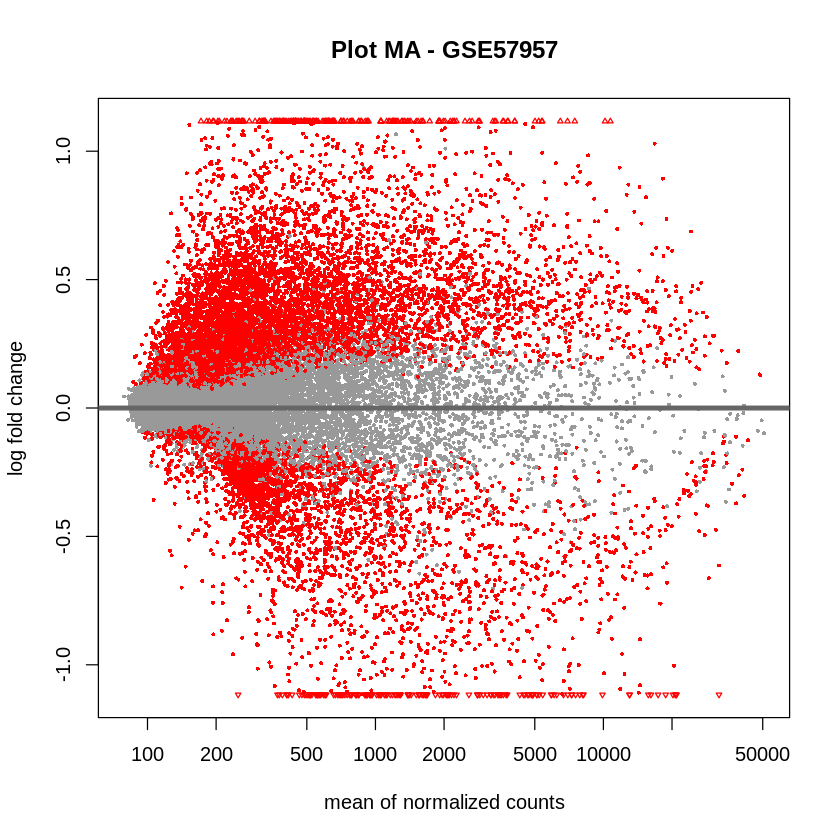

In [ ]:
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")

In [ ]:
# MA plot
jpeg(file=sprintf("Plot MA - %s.jpeg", accessionID))
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")
dev.off()

pdf 
  2

In [ ]:
df <- deseq2_confects(dds, step=0.5)

In [ ]:
df$fdr

[1] 0.05

In [ ]:
df$step

[1] 0.5

In [ ]:
head(df$table)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,1,25856,2.0,4.521492,1344.1814,ILMN_1797519,FALSE
2,2,32403,2.0,3.822312,1909.1008,ILMN_2051972,FALSE
3,3,23597,2.0,3.924447,902.3216,ILMN_1782754,FALSE
4,4,4643,2.0,3.704244,5392.3510,ILMN_1672148,FALSE
5,5,36265,2.0,3.410903,1058.0373,ILMN_2278335,FALSE
6,6,38207,1.5,3.252872,2585.6171,ILMN_2374449,FALSE


In [ ]:
colnames(df$table)

[1] "rank"     "index"    "confect"  "effect"   "baseMean" "name"     "filtered"

In [ ]:
unique(df$table$filtered)

[1] FALSE

In [ ]:
checksums <- df$table %>%
  group_by(filtered) %>%
  summarise(count = n())

In [ ]:
print(checksums)

# A tibble: 1 × 2
  filtered count
  <lgl>    <int>
1 FALSE    47323


In [ ]:
results <- df$table

In [ ]:
#selected_genes <- results[results$filtered == TRUE, ]
selected_genes <- results

In [ ]:
head(selected_genes)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,1,25856,2.0,4.521492,1344.1814,ILMN_1797519,FALSE
2,2,32403,2.0,3.822312,1909.1008,ILMN_2051972,FALSE
3,3,23597,2.0,3.924447,902.3216,ILMN_1782754,FALSE
4,4,4643,2.0,3.704244,5392.3510,ILMN_1672148,FALSE
5,5,36265,2.0,3.410903,1058.0373,ILMN_2278335,FALSE
6,6,38207,1.5,3.252872,2585.6171,ILMN_2374449,FALSE


In [ ]:
# Write values to text file using write.table
write.table(selected_genes$name, file = sprintf("topconfects - %s.txt", accessionID), col.names = FALSE, row.names = FALSE, quote = FALSE)

## GSE62232

In [ ]:
accessionID = "GSE62232"

In [ ]:
# get metadata --------
gse <- getGEO(GEO = accessionID, GSEMatrix = TRUE)
head(gse)

Found 1 file(s)

GSE62232_series_matrix.txt.gz

Using locally cached version: /tmp/RtmpTVkYlS/GSE62232_series_matrix.txt.gz

Using locally cached version of GPL570 found here:
/tmp/RtmpTVkYlS/GPL570.soft.gz 



$GSE62232_series_matrix.txt.gz
ExpressionSet (storageMode: lockedEnvironment)
assayData: 54675 features, 91 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: GSM1523329 GSM1523330 ... GSM1523419 (91 total)
  varLabels: title geo_accession ... tissue:ch1 (43 total)
  varMetadata: labelDescription
featureData
  featureNames: 1007_s_at 1053_at ... AFFX-TrpnX-M_at (54675 total)
  fvarLabels: ID GB_ACC ... Gene Ontology Molecular Function (16 total)
  fvarMetadata: Column Description labelDescription
experimentData: use 'experimentData(object)'
  pubMedIds: 25822088 
Annotation: GPL570 


In [ ]:
countsData <- as.data.frame(exprs(gse[[1]]))

In [ ]:
dim(countsData)

[1] 54675    91

In [ ]:
head(countsData)

,GSM1523329,GSM1523330,GSM1523331,GSM1523332,GSM1523333,GSM1523334,GSM1523335,GSM1523336,GSM1523337,GSM1523338,⋯,GSM1523410,GSM1523411,GSM1523412,GSM1523413,GSM1523414,GSM1523415,GSM1523416,GSM1523417,GSM1523418,GSM1523419
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1007_s_at,133,147,270,290,187,216,199,118,162,103,⋯,171,127,224,340,133,187,315,56,161,184
1053_at,88,86,92,70,76,99,85,85,66,105,⋯,117,91,113,144,85,98,70,80,94,51
117_at,58,48,53,48,66,60,58,67,51,63,⋯,44,42,45,49,76,72,167,35,45,43
121_at,234,201,187,189,191,205,231,222,251,196,⋯,199,203,171,188,171,229,203,123,173,228
1255_g_at,8,9,8,9,8,9,8,9,9,7,⋯,7,10,7,7,8,8,9,8,7,7
1294_at,116,121,101,123,107,93,98,151,116,131,⋯,146,140,165,146,121,132,166,91,113,120


In [ ]:
countsData <- countsData %>% drop_na()

In [ ]:
countsData <- countsData %>% filter(rowSums(.< 0) == 0)

In [ ]:
metaData <- pData(phenoData(gse[[1]]))

In [ ]:
dim(metaData)

[1] 91 43

In [ ]:
head(metaData)

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,⋯,contact_country,supplementary_file,data_row_count,age:ch1,disease state:ch1,edmonson:ch1,etiology:ch1,gender:ch1,metavir:ch1,tissue:ch1
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM1523329,CHC469N,GSM1523329,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523329/suppl/GSM1523329_JZN_0469N_U133_2.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver
GSM1523330,CHC562N,GSM1523330,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523330/suppl/GSM1523330_JZN_0562N_U133_2.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver
GSM1523331,CHC591N,GSM1523331,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523331/suppl/GSM1523331_JZN_0591N_U133_2.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver
GSM1523332,CHC591N.rep2,GSM1523332,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523332/suppl/GSM1523332_JZN_0591N_U133_2.2.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver
GSM1523333,CHC591N.rep3,GSM1523333,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523333/suppl/GSM1523333_JZN_0591N_U133_2.3.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver
GSM1523334,CHC932N,GSM1523334,Public on Dec 31 2014,Oct 09 2014,Dec 31 2014,RNA,1,Non tumor liver,Homo sapiens,tissue: Non tumor liver,⋯,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1523nnn/GSM1523334/suppl/GSM1523334_JZN_0932N_U133_2.2.CEL.gz,54675,NA,Non tumor liver,NA,NA,NA,NA,Non tumor liver


In [ ]:
colnames(metaData)

[1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "characteristics_ch1.2"  
[13] "characteristics_ch1.3"   "characteristics_ch1.4"  
[15] "characteristics_ch1.5"   "characteristics_ch1.6"  
[17] "molecule_ch1"            "extract_protocol_ch1"   
[19] "label_ch1"               "label_protocol_ch1"     
[21] "taxid_ch1"               "hyb_protocol"           
[23] "scan_protocol"           "data_processing"        
[25] "platform_id"             "contact_name"           
[27] "contact_email"           "contact_laboratory"     
[29] "contact_department"      "contact_institute"      
[31] "contact_address"         "contact_city"           
[33] "contact_zip/postal_code" "contact_country"        
[35] "supplementary_file"      "data_row_count"         
[37] "age:ch1"                 "disease state:ch1"      
[39] "edmonson:ch1"            "etiology:ch1"           
[41] "gender:ch1"              "metavir:ch1"            
[43] "tissue:ch1"

In [ ]:
unique(metaData$characteristics_ch1)

[1] "tissue: Non tumor liver"          "tissue: Hepatocellular Carcinoma"

In [ ]:
metaData.modified <- metaData %>%
  select(10) %>%
  mutate(characteristics_ch1 = gsub("tissue: Hepatocellular Carcinoma", "tumor", characteristics_ch1)) %>%
  mutate(characteristics_ch1 = gsub("tissue: Non tumor liver", "non_tumor", characteristics_ch1))
  #rename(tissue = characteristics_ch1) %>%
  #rename(metastasis = characteristics_ch1.1) %>%
  #mutate(tissue = gsub("tissue: ", "", tissue)) %>%
  #mutate(metastasis = gsub("metastasis: ", "", metastasis))

In [ ]:
head(metaData.modified)

,characteristics_ch1
,<chr>
GSM1523329,non_tumor
GSM1523330,non_tumor
GSM1523331,non_tumor
GSM1523332,non_tumor
GSM1523333,non_tumor
GSM1523334,non_tumor


In [ ]:
unique(metaData.modified$characteristics_ch1)

[1] "non_tumor" "tumor"

In [ ]:
table(metaData.modified$characteristics_ch1)


non_tumor     tumor 
       10        81 

In [ ]:
# Make sure the row names in metaData matches to column names in countsData
all(colnames(countsData) %in% rownames(metaData.modified))

[1] TRUE

In [ ]:
# Make sure the row names in metaData is in the same order with the column names in countsData
all(colnames(countsData) == rownames(metaData.modified))

[1] TRUE

In [ ]:
any(is.na(countsData))

[1] FALSE

In [ ]:
any(countsData < 0)

[1] FALSE

In [ ]:
dds <- DESeqDataSetFromMatrix(countData = round(countsData),
                       colData = metaData.modified,
                       design = ~ characteristics_ch1)

dds

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 54675 91 
metadata(1): version
assays(1): counts
rownames(54675): 1007_s_at 1053_at ... AFFX-TrpnX-5_at AFFX-TrpnX-M_at
rowData names(0):
colnames(91): GSM1523329 GSM1523330 ... GSM1523418 GSM1523419
colData names(1): characteristics_ch1

In [ ]:
# Pre-filtering: remove rows with low gene counts; keep rows that have at least 100 reads total
keep <- rowSums(counts(dds)) >= 100
dds <- dds[keep,]

dds

class: DESeqDataSet 
dim: 54675 91 
metadata(1): version
assays(1): counts
rownames(54675): 1007_s_at 1053_at ... AFFX-TrpnX-5_at AFFX-TrpnX-M_at
rowData names(0):
colnames(91): GSM1523329 GSM1523330 ... GSM1523418 GSM1523419
colData names(1): characteristics_ch1

In [ ]:
dds

class: DESeqDataSet 
dim: 54675 91 
metadata(1): version
assays(1): counts
rownames(54675): 1007_s_at 1053_at ... AFFX-TrpnX-5_at AFFX-TrpnX-M_at
rowData names(0):
colnames(91): GSM1523329 GSM1523330 ... GSM1523418 GSM1523419
colData names(1): characteristics_ch1

In [ ]:
# set the factor level
dds$characteristics_ch1 <- relevel(dds$characteristics_ch1, ref = "non_tumor")

In [ ]:
# Step 3: Run DESeq ----------------------
dds <- DESeq(dds)
res <- results(dds)

res

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 883 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54675 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat      pvalue
                <numeric>      <numeric> <numeric>  <numeric>   <numeric>
1007_s_at       236.07011      0.4323417 0.2280076    1.89617 5.79372e-02
1053_at         124.82472      0.6223193 0.1565023    3.97642 6.99599e-05
117_at           67.08687      0.2717037 0.2509335    1.08277 2.78910e-01
121_at          199.82031     -0.0672515 0.0666577   -1.00891 3.13019e-01
1255_g_at         8.03227     -0.0539109 0.1719647   -0.31350 7.53901e-01
...                   ...            ...       ...        ...         ...
AFFX-ThrX-5_at    9.04397    -0.16122654  0.157892 -1.0211216    0.307197
AFFX-ThrX-M_at    6.31683    -0.05245516  0.193793 -0.2706769    0.786640
AFFX-TrpnX-3_at   5.29533     0.01642263  0.215354  0.0762588    0.939213
AFFX-TrpnX-5_at   8.379

In [ ]:
# Explore Results ----------------

summary(res)


out of 54675 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 13146, 24%
LFC < 0 (down)     : 6543, 12%
outliers [1]       : 0, 0%
low counts [2]     : 9541, 17%
(mean count < 10)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res

log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54675 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat      pvalue
                <numeric>      <numeric> <numeric>  <numeric>   <numeric>
1007_s_at       236.07011      0.4323417 0.2280076    1.89617 5.79372e-02
1053_at         124.82472      0.6223193 0.1565023    3.97642 6.99599e-05
117_at           67.08687      0.2717037 0.2509335    1.08277 2.78910e-01
121_at          199.82031     -0.0672515 0.0666577   -1.00891 3.13019e-01
1255_g_at         8.03227     -0.0539109 0.1719647   -0.31350 7.53901e-01
...                   ...            ...       ...        ...         ...
AFFX-ThrX-5_at    9.04397    -0.16122654  0.157892 -1.0211216    0.307197
AFFX-ThrX-M_at    6.31683    -0.05245516  0.193793 -0.2706769    0.786640
AFFX-TrpnX-3_at   5.29533     0.01642263  0.215354  0.0762588    0.939213
AFFX-TrpnX-5_at   8.379

In [ ]:
res0.05 <- results(dds, alpha = 0.05)
summary(res0.05)


out of 54675 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 11273, 21%
LFC < 0 (down)     : 5017, 9.2%
outliers [1]       : 0, 0%
low counts [2]     : 9541, 17%
(mean count < 10)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res0.05

log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54675 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat      pvalue
                <numeric>      <numeric> <numeric>  <numeric>   <numeric>
1007_s_at       236.07011      0.4323417 0.2280076    1.89617 5.79372e-02
1053_at         124.82472      0.6223193 0.1565023    3.97642 6.99599e-05
117_at           67.08687      0.2717037 0.2509335    1.08277 2.78910e-01
121_at          199.82031     -0.0672515 0.0666577   -1.00891 3.13019e-01
1255_g_at         8.03227     -0.0539109 0.1719647   -0.31350 7.53901e-01
...                   ...            ...       ...        ...         ...
AFFX-ThrX-5_at    9.04397    -0.16122654  0.157892 -1.0211216    0.307197
AFFX-ThrX-M_at    6.31683    -0.05245516  0.193793 -0.2706769    0.786640
AFFX-TrpnX-3_at   5.29533     0.01642263  0.215354  0.0762588    0.939213
AFFX-TrpnX-5_at   8.379

In [ ]:
res = as.data.frame(res0.05)

In [ ]:
any(is.na(res))

[1] TRUE

In [ ]:
res <- res %>% drop_na()

In [ ]:
res$diffexpressed <- ifelse(res$log2FoldChange > 0 & res$padj < 0.05, "UP",
                       ifelse(res$log2FoldChange < 0 & res$padj < 0.05, "DOWN", "N0"))

res$delabel <- "NA"

In [ ]:
table(res$diffexpressed)


 DOWN    N0    UP 
 5017 28844 11273 

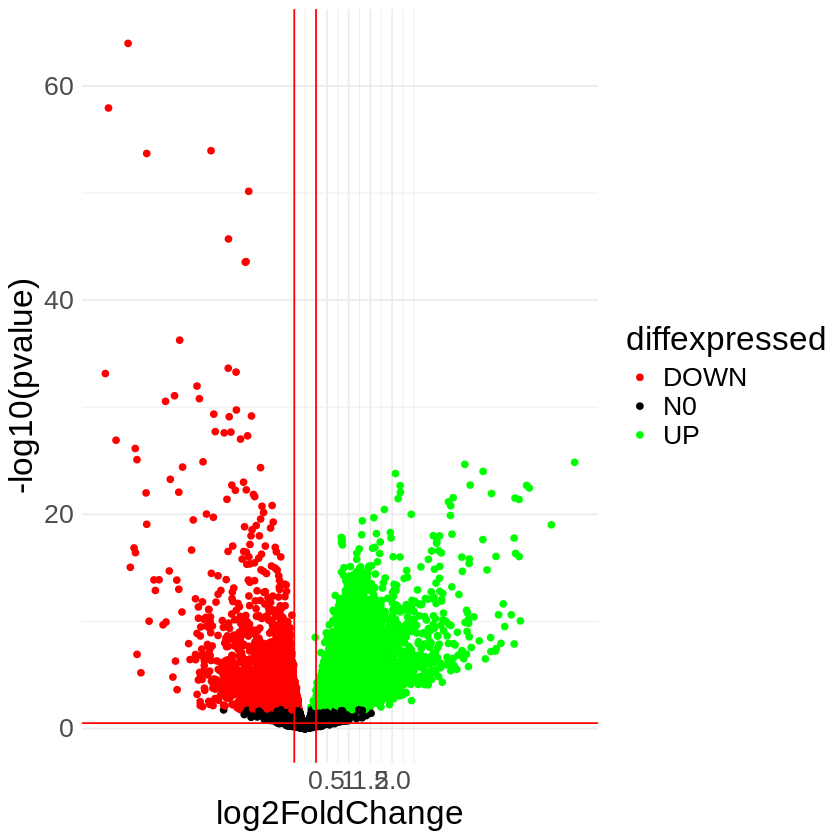

In [ ]:
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0.5, 2, by = 0.5), labels = c("0.5", "1", "1.5", "2.0")) +
    geom_vline(xintercept = c(-0.25,  0.25), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))

In [ ]:
# Volcano plot
jpeg(file=sprintf("Volcano Plot - %s.jpeg", accessionID), width = 800, height = 800)
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0.5, 2, by = 0.5), labels = c("0.5", "1", "1.5", "2.0")) +
    geom_vline(xintercept = c(-0.25,  0.25), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))
dev.off()

pdf 
  2

In [ ]:
# contrasts
resultsNames(dds)

[1] "Intercept"                             
[2] "characteristics_ch1_tumor_vs_non_tumor"

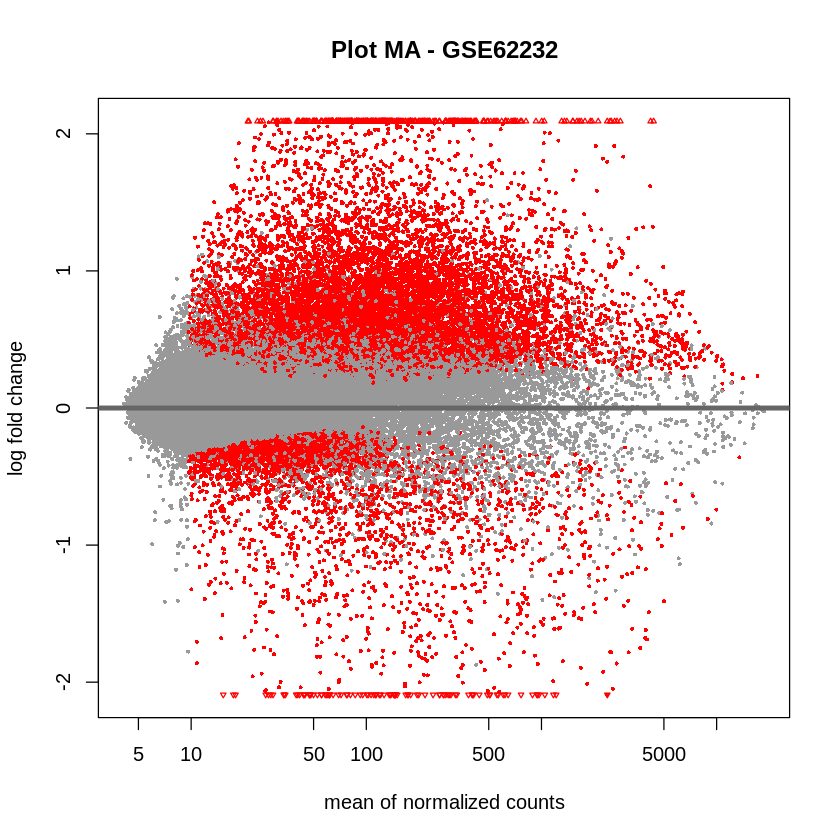

In [ ]:
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")

In [ ]:
# MA plot
jpeg(file=sprintf("Plot MA - %s.jpeg", accessionID))
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")
dev.off()

pdf 
  2

In [ ]:
df <- deseq2_confects(dds, step=0.5)

In [ ]:
df$fdr

[1] 0.05

In [ ]:
df$step

[1] 0.5

In [ ]:
head(df$table)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,1,16008,3.0,6.193837,4366.60422,206561_s_at,FALSE
2,2,25351,-3.0,-4.520439,240.42479,216058_s_at,FALSE
3,3,17427,-2.5,-4.070572,48.21241,207995_s_at,FALSE
4,4,18635,2.5,5.659376,1685.58946,209220_at,FALSE
5,5,16775,-2.5,-4.592223,284.08087,207330_at,FALSE
6,6,14448,2.5,5.150688,178.91001,205000_at,FALSE


In [ ]:
colnames(df$table)

[1] "rank"     "index"    "confect"  "effect"   "baseMean" "name"     "filtered"

In [ ]:
unique(df$table$filtered)

[1] FALSE  TRUE

In [ ]:
checksums <- df$table %>%
  group_by(filtered) %>%
  summarise(count = n())

In [ ]:
print(checksums)

# A tibble: 2 × 2
  filtered count
  <lgl>    <int>
1 FALSE    45134
2 TRUE      9541


In [ ]:
results <- df$table

In [ ]:
selected_genes <- results[results$filtered == TRUE, ]

In [ ]:
head(selected_genes)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
45135,45135,5,NA,-0.05391091,8.032272,1255_g_at,TRUE
45136,45136,20,NA,0.03268226,7.663712,1552266_at,TRUE
45137,45137,21,NA,0.07615806,6.949059,1552269_at,TRUE
45138,45138,40,NA,0.02335713,7.830622,1552296_at,TRUE
45139,45139,57,NA,-0.01767025,7.431880,1552320_a_at,TRUE
45140,45140,58,NA,-0.03094829,5.917858,1552321_a_at,TRUE


In [ ]:
# Write values to text file using write.table
write.table(selected_genes$name, file = sprintf("topconfects - %s.txt", accessionID), col.names = FALSE, row.names = FALSE, quote = FALSE)

## GSE112790

In [ ]:
accessionID = "GSE112790"

In [ ]:
# get metadata --------
gse <- getGEO(GEO = accessionID, GSEMatrix = TRUE)
head(gse)

Found 1 file(s)

GSE112790_series_matrix.txt.gz

Using locally cached version: /tmp/RtmpTVkYlS/GSE112790_series_matrix.txt.gz

Using locally cached version of GPL570 found here:
/tmp/RtmpTVkYlS/GPL570.soft.gz 



$GSE112790_series_matrix.txt.gz
ExpressionSet (storageMode: lockedEnvironment)
assayData: 54613 features, 198 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: GSM3083512 GSM3083513 ... GSM3083709 (198 total)
  varLabels: title geo_accession ... tissue:ch1 (33 total)
  varMetadata: labelDescription
featureData
  featureNames: 1007_s_at 1053_at ... 91952_at (54613 total)
  fvarLabels: ID GB_ACC ... Gene Ontology Molecular Function (16 total)
  fvarMetadata: Column Description labelDescription
experimentData: use 'experimentData(object)'
  pubMedIds: 30598371 
Annotation: GPL570 


In [ ]:
countsData <- as.data.frame(exprs(gse[[1]]))

In [ ]:
dim(countsData)

[1] 54613   198

In [ ]:
head(countsData)

,GSM3083512,GSM3083513,GSM3083514,GSM3083515,GSM3083516,GSM3083517,GSM3083518,GSM3083519,GSM3083520,GSM3083521,⋯,GSM3083700,GSM3083701,GSM3083702,GSM3083703,GSM3083704,GSM3083705,GSM3083706,GSM3083707,GSM3083708,GSM3083709
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1007_s_at,8.732243,7.700962,7.430437,7.413390,7.826904,8.187389,7.552334,7.606355,7.325860,7.689149,⋯,7.234797,8.626162,8.109836,10.906406,6.913781,7.652772,10.824916,7.092559,7.714057,8.386094
1053_at,6.537006,6.947477,7.016427,7.244579,6.865427,6.817964,6.893700,6.136600,6.859644,7.038027,⋯,7.311774,5.891430,6.685165,8.473204,7.324122,6.531240,7.873370,6.348047,6.974386,7.580749
117_at,5.355570,6.304068,5.982764,5.754301,6.734848,5.817140,5.969089,6.182312,6.082924,6.032658,⋯,6.817004,5.875040,12.344321,5.993394,5.494260,7.705957,5.266337,6.921801,8.334629,5.442079
121_at,8.157240,8.087541,8.036149,8.006034,7.833921,7.845737,7.941155,7.892897,8.003834,7.882961,⋯,8.384794,7.649207,8.208775,6.979202,7.577418,7.415163,7.944191,7.480682,7.451438,7.940523
1255_g_at,3.003003,3.186045,3.201874,3.031305,3.011914,3.002118,3.154288,2.973173,2.946693,3.214547,⋯,3.106223,3.110743,3.191020,3.093092,3.239174,3.070465,3.011797,3.269521,3.316881,3.231922
1294_at,6.804490,7.009626,7.377234,7.312078,7.251009,6.922467,7.253043,7.631976,7.528560,7.009010,⋯,7.789191,7.711038,8.091701,8.571132,7.526961,7.707716,6.124023,7.923103,7.685886,7.536512


In [ ]:
countsData <- countsData %>% drop_na()

In [ ]:
countsData <- countsData %>% filter(rowSums(.< 0) == 0)

In [ ]:
metaData <- pData(phenoData(gse[[1]]))

In [ ]:
dim(metaData)

[1] 198  33

In [ ]:
head(metaData)

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,⋯,contact_department,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,data_row_count,tissue:ch1
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM3083512,NL001,GSM3083512,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL001,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083512/suppl/GSM3083512_NL001.CEL.gz,54613,Normal liver
GSM3083513,NL002,GSM3083513,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL002,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083513/suppl/GSM3083513_NL002.CEL.gz,54613,Normal liver
GSM3083514,NL003,GSM3083514,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL003,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083514/suppl/GSM3083514_NL003.CEL.gz,54613,Normal liver
GSM3083515,NL004,GSM3083515,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL004,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083515/suppl/GSM3083515_NL004.CEL.gz,54613,Normal liver
GSM3083516,NL005,GSM3083516,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL005,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083516/suppl/GSM3083516_NL005.CEL.gz,54613,Normal liver
GSM3083517,NL006,GSM3083517,Public on Jan 03 2019,Apr 06 2018,Jan 03 2019,RNA,1,Human normal liver #NL006,Homo sapiens,tissue: Normal liver,⋯,Department of Molecular Oncology,Tokyo Medical and Dental University,1-5-45 Yushima,Bunkyo-ku,Tokyo,113-8519,Japan,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3083nnn/GSM3083517/suppl/GSM3083517_NL006.CEL.gz,54613,Normal liver


In [ ]:
colnames(metaData)

[1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "treatment_protocol_ch1"  "molecule_ch1"           
[13] "extract_protocol_ch1"    "label_ch1"              
[15] "label_protocol_ch1"      "taxid_ch1"              
[17] "hyb_protocol"            "scan_protocol"          
[19] "data_processing"         "platform_id"            
[21] "contact_name"            "contact_email"          
[23] "contact_phone"           "contact_department"     
[25] "contact_institute"       "contact_address"        
[27] "contact_city"            "contact_state"          
[29] "contact_zip/postal_code" "contact_country"        
[31] "supplementary_file"      "data_row_count"         
[33] "tissue:ch1"

In [ ]:
unique(metaData$characteristics_ch1)

[1] "tissue: Normal liver"                
[2] "tissue: liver cancer tumorous tissue"

In [ ]:
metaData.modified <- metaData %>%
  select(10) %>%
  mutate(characteristics_ch1 = gsub("tissue: liver cancer tumorous tissue", "tumor", characteristics_ch1)) %>%
  mutate(characteristics_ch1 = gsub("tissue: Normal liver", "non_tumor", characteristics_ch1))
  #rename(tissue = characteristics_ch1) %>%
  #rename(metastasis = characteristics_ch1.1) %>%
  #mutate(tissue = gsub("tissue: ", "", tissue)) %>%
  #mutate(metastasis = gsub("metastasis: ", "", metastasis))

In [ ]:
head(metaData.modified)

,characteristics_ch1
,<chr>
GSM3083512,non_tumor
GSM3083513,non_tumor
GSM3083514,non_tumor
GSM3083515,non_tumor
GSM3083516,non_tumor
GSM3083517,non_tumor


In [ ]:
unique(metaData.modified$characteristics_ch1)

[1] "non_tumor" "tumor"

In [ ]:
table(metaData.modified$characteristics_ch1)


non_tumor     tumor 
       15       183 

In [ ]:
# Make sure the row names in metaData matches to column names in countsData
all(colnames(countsData) %in% rownames(metaData.modified))

[1] TRUE

In [ ]:
# Make sure the row names in metaData is in the same order with the column names in countsData
all(colnames(countsData) == rownames(metaData.modified))

[1] TRUE

In [ ]:
any(is.na(countsData))

[1] FALSE

In [ ]:
any(countsData < 0)

[1] FALSE

In [ ]:
dds <- DESeqDataSetFromMatrix(countData = round(countsData),
                       colData = metaData.modified,
                       design = ~ characteristics_ch1)

dds

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 54613 198 
metadata(1): version
assays(1): counts
rownames(54613): 1007_s_at 1053_at ... 91920_at 91952_at
rowData names(0):
colnames(198): GSM3083512 GSM3083513 ... GSM3083708 GSM3083709
colData names(1): characteristics_ch1

In [ ]:
# Pre-filtering: remove rows with low gene counts; keep rows that have at least 100 reads total
keep <- rowSums(counts(dds)) >= 100
dds <- dds[keep,]

dds

class: DESeqDataSet 
dim: 54613 198 
metadata(1): version
assays(1): counts
rownames(54613): 1007_s_at 1053_at ... 91920_at 91952_at
rowData names(0):
colnames(198): GSM3083512 GSM3083513 ... GSM3083708 GSM3083709
colData names(1): characteristics_ch1

In [ ]:
dds

class: DESeqDataSet 
dim: 54613 198 
metadata(1): version
assays(1): counts
rownames(54613): 1007_s_at 1053_at ... 91920_at 91952_at
rowData names(0):
colnames(198): GSM3083512 GSM3083513 ... GSM3083708 GSM3083709
colData names(1): characteristics_ch1

In [ ]:
# set the factor level
dds$characteristics_ch1 <- relevel(dds$characteristics_ch1, ref = "non_tumor")

In [ ]:
# Step 3: Run DESeq ----------------------
dds <- DESeq(dds)
res <- results(dds)

res

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54613 rows and 6 columns
            baseMean log2FoldChange     lfcSE       stat    pvalue      padj
           <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
1007_s_at    8.19402     0.07220228  0.139539  0.5174339  0.604853  0.999998
1053_at      7.31175     0.09322202  0.148922  0.6259790  0.531329  0.999998
117_at       6.15048     0.01684277  0.160173  0.1051536  0.916254  0.999998
121_at       7.97550    -0.00929059  0.138135 -0.0672575  0.946377  0.999998
1255_g_at    3.01675     0.00421435  0.227744  0.0185048  0.985236        NA
...              ...            ...       ...        ...       ...       ...
91703_at     5.96282      0.0208115  0.162793   0.127840  0.898276  0.999998
91816_f_at   5.86634      0.0494750  0.165767   0.298461  0.765352  0.999998
91826_at     5.49095     -0.1258517  0.162541  -0.774279  0.438766 

In [ ]:
# Explore Results ----------------

summary(res)


out of 54613 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 63, 0.12%
LFC < 0 (down)     : 121, 0.22%
outliers [1]       : 0, 0%
low counts [2]     : 7412, 14%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res

log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54613 rows and 6 columns
            baseMean log2FoldChange     lfcSE       stat    pvalue      padj
           <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
1007_s_at    8.19402     0.07220228  0.139539  0.5174339  0.604853  0.999998
1053_at      7.31175     0.09322202  0.148922  0.6259790  0.531329  0.999998
117_at       6.15048     0.01684277  0.160173  0.1051536  0.916254  0.999998
121_at       7.97550    -0.00929059  0.138135 -0.0672575  0.946377  0.999998
1255_g_at    3.01675     0.00421435  0.227744  0.0185048  0.985236        NA
...              ...            ...       ...        ...       ...       ...
91703_at     5.96282      0.0208115  0.162793   0.127840  0.898276  0.999998
91816_f_at   5.86634      0.0494750  0.165767   0.298461  0.765352  0.999998
91826_at     5.49095     -0.1258517  0.162541  -0.774279  0.438766 

In [ ]:
res0.05 <- results(dds, alpha = 0.05)
summary(res0.05)


out of 54613 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 45, 0.082%
LFC < 0 (down)     : 86, 0.16%
outliers [1]       : 0, 0%
low counts [2]     : 6353, 12%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:
res0.05

log2 fold change (MLE): characteristics ch1 tumor vs non tumor 
Wald test p-value: characteristics ch1 tumor vs non tumor 
DataFrame with 54613 rows and 6 columns
            baseMean log2FoldChange     lfcSE       stat    pvalue      padj
           <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
1007_s_at    8.19402     0.07220228  0.139539  0.5174339  0.604853  0.999998
1053_at      7.31175     0.09322202  0.148922  0.6259790  0.531329  0.999998
117_at       6.15048     0.01684277  0.160173  0.1051536  0.916254  0.999998
121_at       7.97550    -0.00929059  0.138135 -0.0672575  0.946377  0.999998
1255_g_at    3.01675     0.00421435  0.227744  0.0185048  0.985236        NA
...              ...            ...       ...        ...       ...       ...
91703_at     5.96282      0.0208115  0.162793   0.127840  0.898276  0.999998
91816_f_at   5.86634      0.0494750  0.165767   0.298461  0.765352  0.999998
91826_at     5.49095     -0.1258517  0.162541  -0.774279  0.438766 

In [ ]:
res = as.data.frame(res0.05)

In [ ]:
any(is.na(res))

[1] TRUE

In [ ]:
res <- res %>% drop_na()

In [ ]:
res$diffexpressed <- ifelse(res$log2FoldChange > 0 & res$padj < 0.05, "UP",
                       ifelse(res$log2FoldChange < 0 & res$padj < 0.05, "DOWN", "N0"))

res$delabel <- "NA"

In [ ]:
table(res$diffexpressed)


 DOWN    N0    UP 
   86 48129    45 

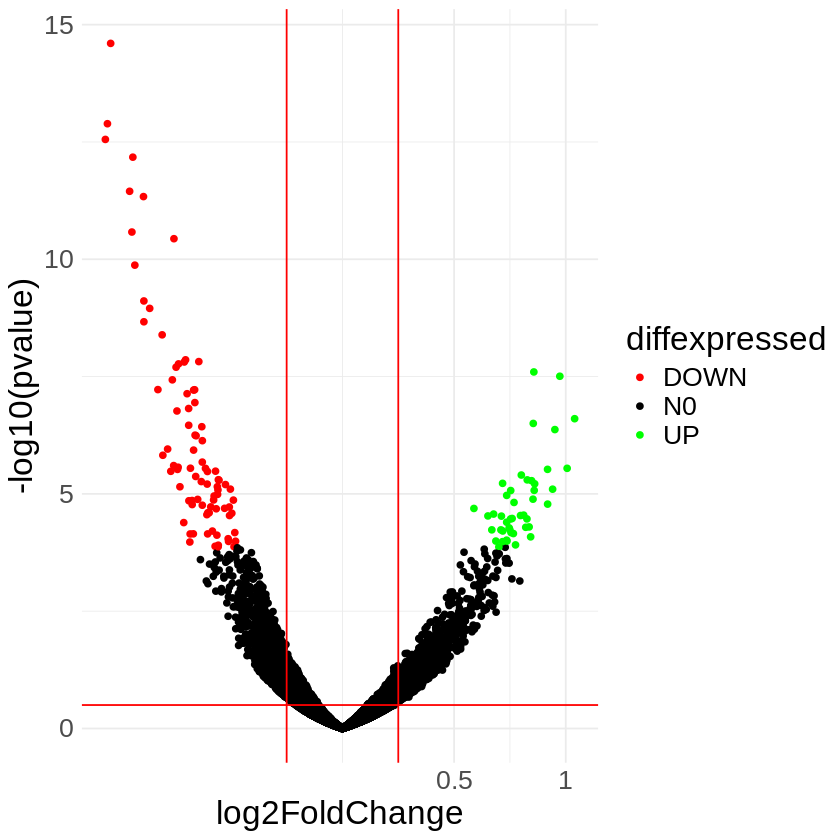

In [ ]:
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0.5, 2, by = 0.5), labels = c("0.5", "1", "1.5", "2.0")) +
    geom_vline(xintercept = c(-0.25,  0.25), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))

In [ ]:
# Volcano plot
jpeg(file=sprintf("Volcano Plot - %s.jpeg", accessionID), width = 800, height = 800)
ggplot(data=res, aes(x=log2FoldChange, y=-log10(pvalue), col=diffexpressed, label=delabel)) +
    geom_point() +
    theme_minimal() +
    scale_color_manual(values=c("red", "black", "green")) +
    scale_x_continuous(breaks = seq(0.5, 2, by = 0.5), labels = c("0.5", "1", "1.5", "2.0")) +
    geom_vline(xintercept = c(-0.25,  0.25), col="red") +
    geom_hline(yintercept = 0.5, col="red") +
    theme(text = element_text(size=20))
dev.off()

pdf 
  2

In [ ]:
# contrasts
resultsNames(dds)

[1] "Intercept"                             
[2] "characteristics_ch1_tumor_vs_non_tumor"

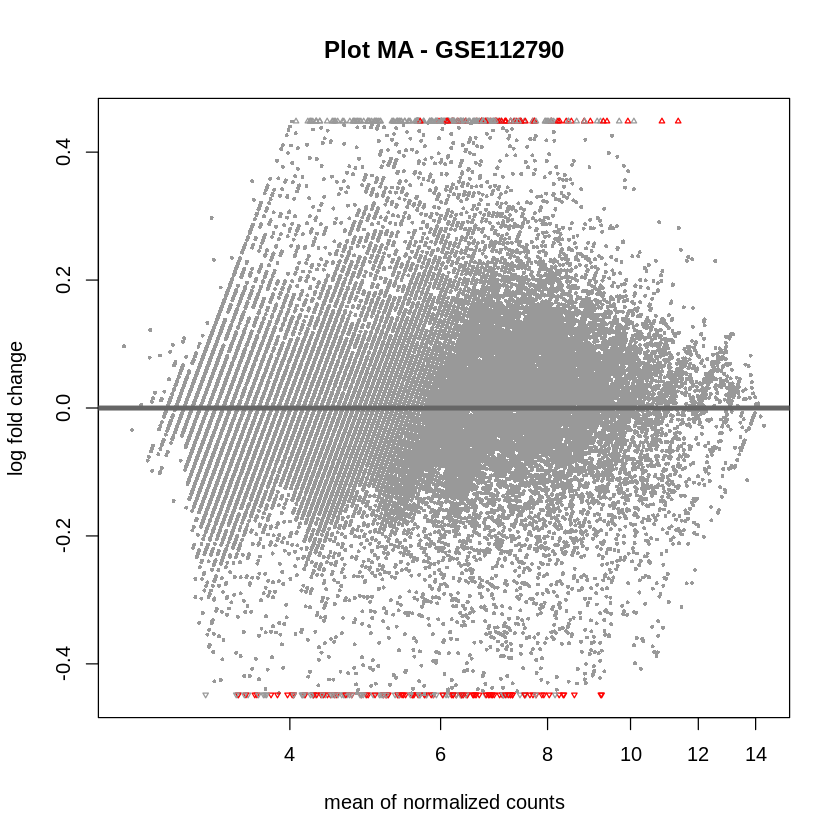

In [ ]:
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")

In [ ]:
# MA plot
jpeg(file=sprintf("Plot MA - %s.jpeg", accessionID))
plotMA(res0.05, main=sprintf("Plot MA - %s", accessionID), colSig="red")
dev.off()

pdf 
  2

In [ ]:
df <- deseq2_confects(dds, step=0.5)

In [ ]:
df$fdr

[1] 0.05

In [ ]:
df$step

[1] 0.5

In [ ]:
head(df$table)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,1,4867,0,-1.0381674,5.343371,1559573_at,FALSE
2,2,17246,0,-1.0526441,4.461085,207804_s_at,FALSE
3,3,29401,0,-1.0618959,4.263835,220116_at,FALSE
4,4,32976,0,-0.9388415,5.744131,223699_at,FALSE
5,5,31764,0,-0.9532144,5.029285,222484_s_at,FALSE
6,6,29781,0,-0.9430657,4.725099,220496_at,FALSE


In [ ]:
colnames(df$table)

[1] "rank"     "index"    "confect"  "effect"   "baseMean" "name"     "filtered"

In [ ]:
unique(df$table$filtered)

[1] FALSE  TRUE

In [ ]:
checksums <- df$table %>%
  group_by(filtered) %>%
  summarise(count = n())

In [ ]:
print(checksums)

# A tibble: 2 × 2
  filtered count
  <lgl>    <int>
1 FALSE    47201
2 TRUE      7412


In [ ]:
results <- df$table

In [ ]:
selected_genes <- results[results$filtered == TRUE, ]

In [ ]:
head(selected_genes)

,rank,index,confect,effect,baseMean,name,filtered
,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
47202,47202,5,NA,0.004214348,3.016754,1255_g_at,TRUE
47203,47203,20,NA,-0.034832913,3.138434,1552266_at,TRUE
47204,47204,21,NA,0.003106345,3.148725,1552269_at,TRUE
47205,47205,57,NA,0.025050613,3.057469,1552320_a_at,TRUE
47206,47206,58,NA,-0.001499053,3.072707,1552321_a_at,TRUE
47207,47207,59,NA,0.004217129,3.016904,1552322_at,TRUE


In [ ]:
# Write values to text file using write.table
write.table(selected_genes$name, file = sprintf("topconfects - %s.txt", accessionID), col.names = FALSE, row.names = FALSE, quote = FALSE)